---
title: Joint probability inference
---


In [1]:
import msprime
import pandas as pd
import numpy as np
import sgkit as sg
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

In [ ]:
path = "/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz"

ds = sg.load_dataset(path)
keep = ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203']
mask = ds["sample_id"].isin(keep).values
ds_sub = ds.isel(samples=mask)
nr_samples = ds_sub.sizes["samples"] 

gt = ds_sub["call_genotype"]

counts = gt.sum(dim=["samples", "ploidy"]).values
positions = ds_sub["variant_position"].values.astype(int)
rec_rate = 1e-8
gen_pos = positions * rec_rate
df = pd.DataFrame({
    "pos": positions,
    "gen_pos": gen_pos,
    "count": counts
})
df.to_csv("baboon_data_derived_counts.csv", index=False)


In [ ]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("baboon_data_derived_counts.csv")

df = df.sort_values("pos").reset_index(drop=True)
col = "pos" 
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()


In [16]:

mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()


,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


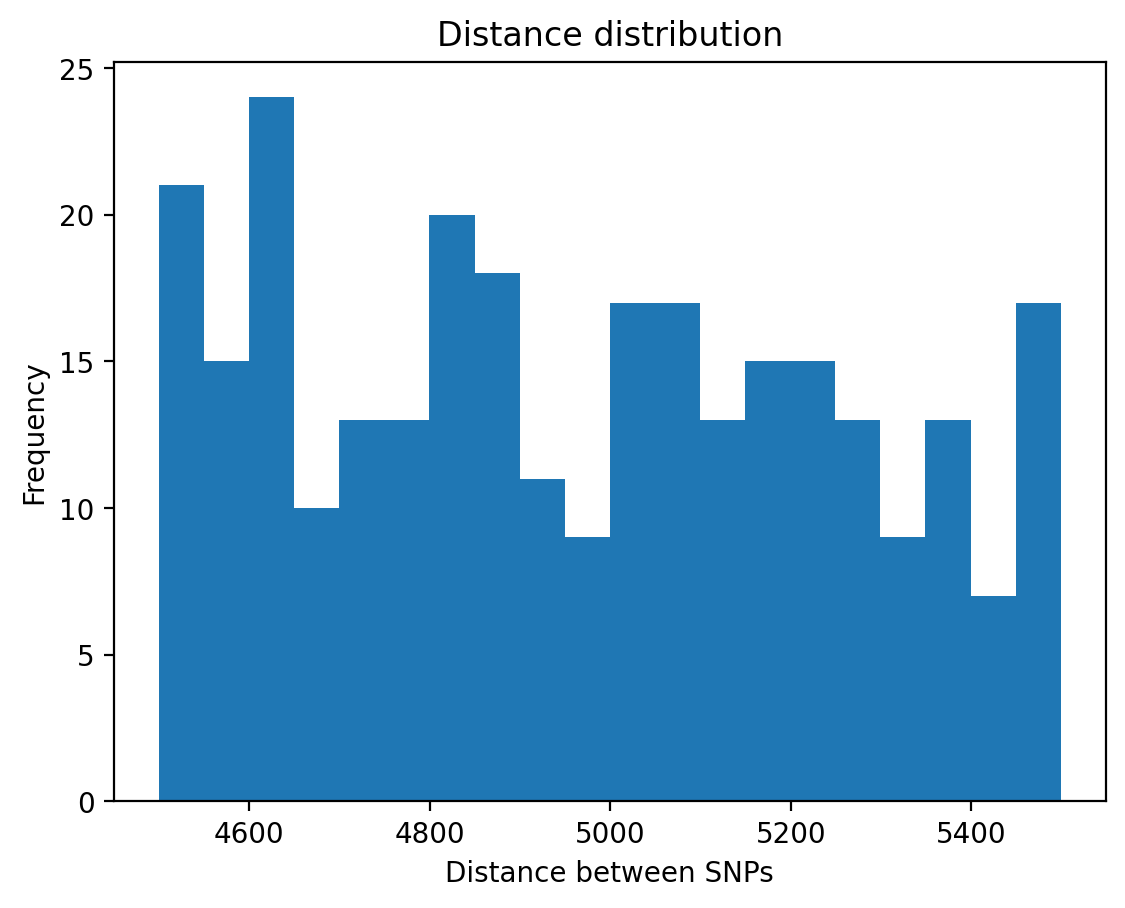

In [17]:

plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=20)
plt.xlabel("Distance between SNPs")
plt.ylabel("Frequency")
plt.title("Distance distribution")
plt.show()


In [18]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
   observations[i, pair] = 1


In [19]:
msg = f"""
Two-locus observations from baboon data:
    Number of samples: {nr_samples}
    Number of SNP pairs: {n}
    Distance window: {distance} ± {tolerance} bp
"""

print(msg)


Two-locus observations from baboon data:
    Number of samples: 5
    Number of SNP pairs: 290
    Distance window: 5000 ± 500 bp

